# Data Visualization

In [2]:
# install requirements

# if connected to colab

if 'google.colab' in str(get_ipython()):
  print('running on colab')
  !git clone https://github.com/ongarileonardo/galaxy_class.git
  %cd galaxy_class

%pip install -r galaxy10-requirements.txt

  Cloning https://github.com/henrysky/astroNN.git to /private/var/folders/fs/k53t7dxj1zqbyfqnmt7mn8r80000gn/T/pip-req-build-vavghq1x
  Running command git clone --filter=blob:none --quiet https://github.com/henrysky/astroNN.git /private/var/folders/fs/k53t7dxj1zqbyfqnmt7mn8r80000gn/T/pip-req-build-vavghq1x
  Resolved https://github.com/henrysky/astroNN.git to commit 75c43a8e86c85d8ed18d15c5c613015af28a2a11
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

# import everything we need first
from keras import utils
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from astroNN.datasets import load_galaxy10sdss
from astroNN.datasets.galaxy10sdss import galaxy10cls_lookup

In [4]:
# To load images and labels (will download automatically at the first time)
# First time downloading location will be ~/.astroNN/datasets/
images, labels = load_galaxy10sdss()

/Users/leo/.astroNN/datasets/Galaxy10.h5 was found!


In [5]:
images.shape

(21785, 69, 69, 3)

In [6]:
# To convert the labels to categorical 10 classes
labels = utils.to_categorical(labels, 10)

# (one hot encoding)
labels

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 0.]])

In [7]:
# def center_crop(img, crop_size):
#     h, w = img.shape[:2]
#     start_h = (h - crop_size) // 2
#     start_w = (w - crop_size) // 2
#     return img[start_h:start_h + crop_size, start_w:start_w + crop_size]

# crop_size = 128
# images_small = np.array([center_crop(img, crop_size) for img in images])
# print(images_small.shape, images_small.nbytes / 1e9, "GB")

In [8]:
from PIL import Image
import numpy as np

images_gray = np.array([
    np.array(Image.fromarray(img).convert('L')) for img in images
])

print(images_gray.shape)

(21785, 69, 69)


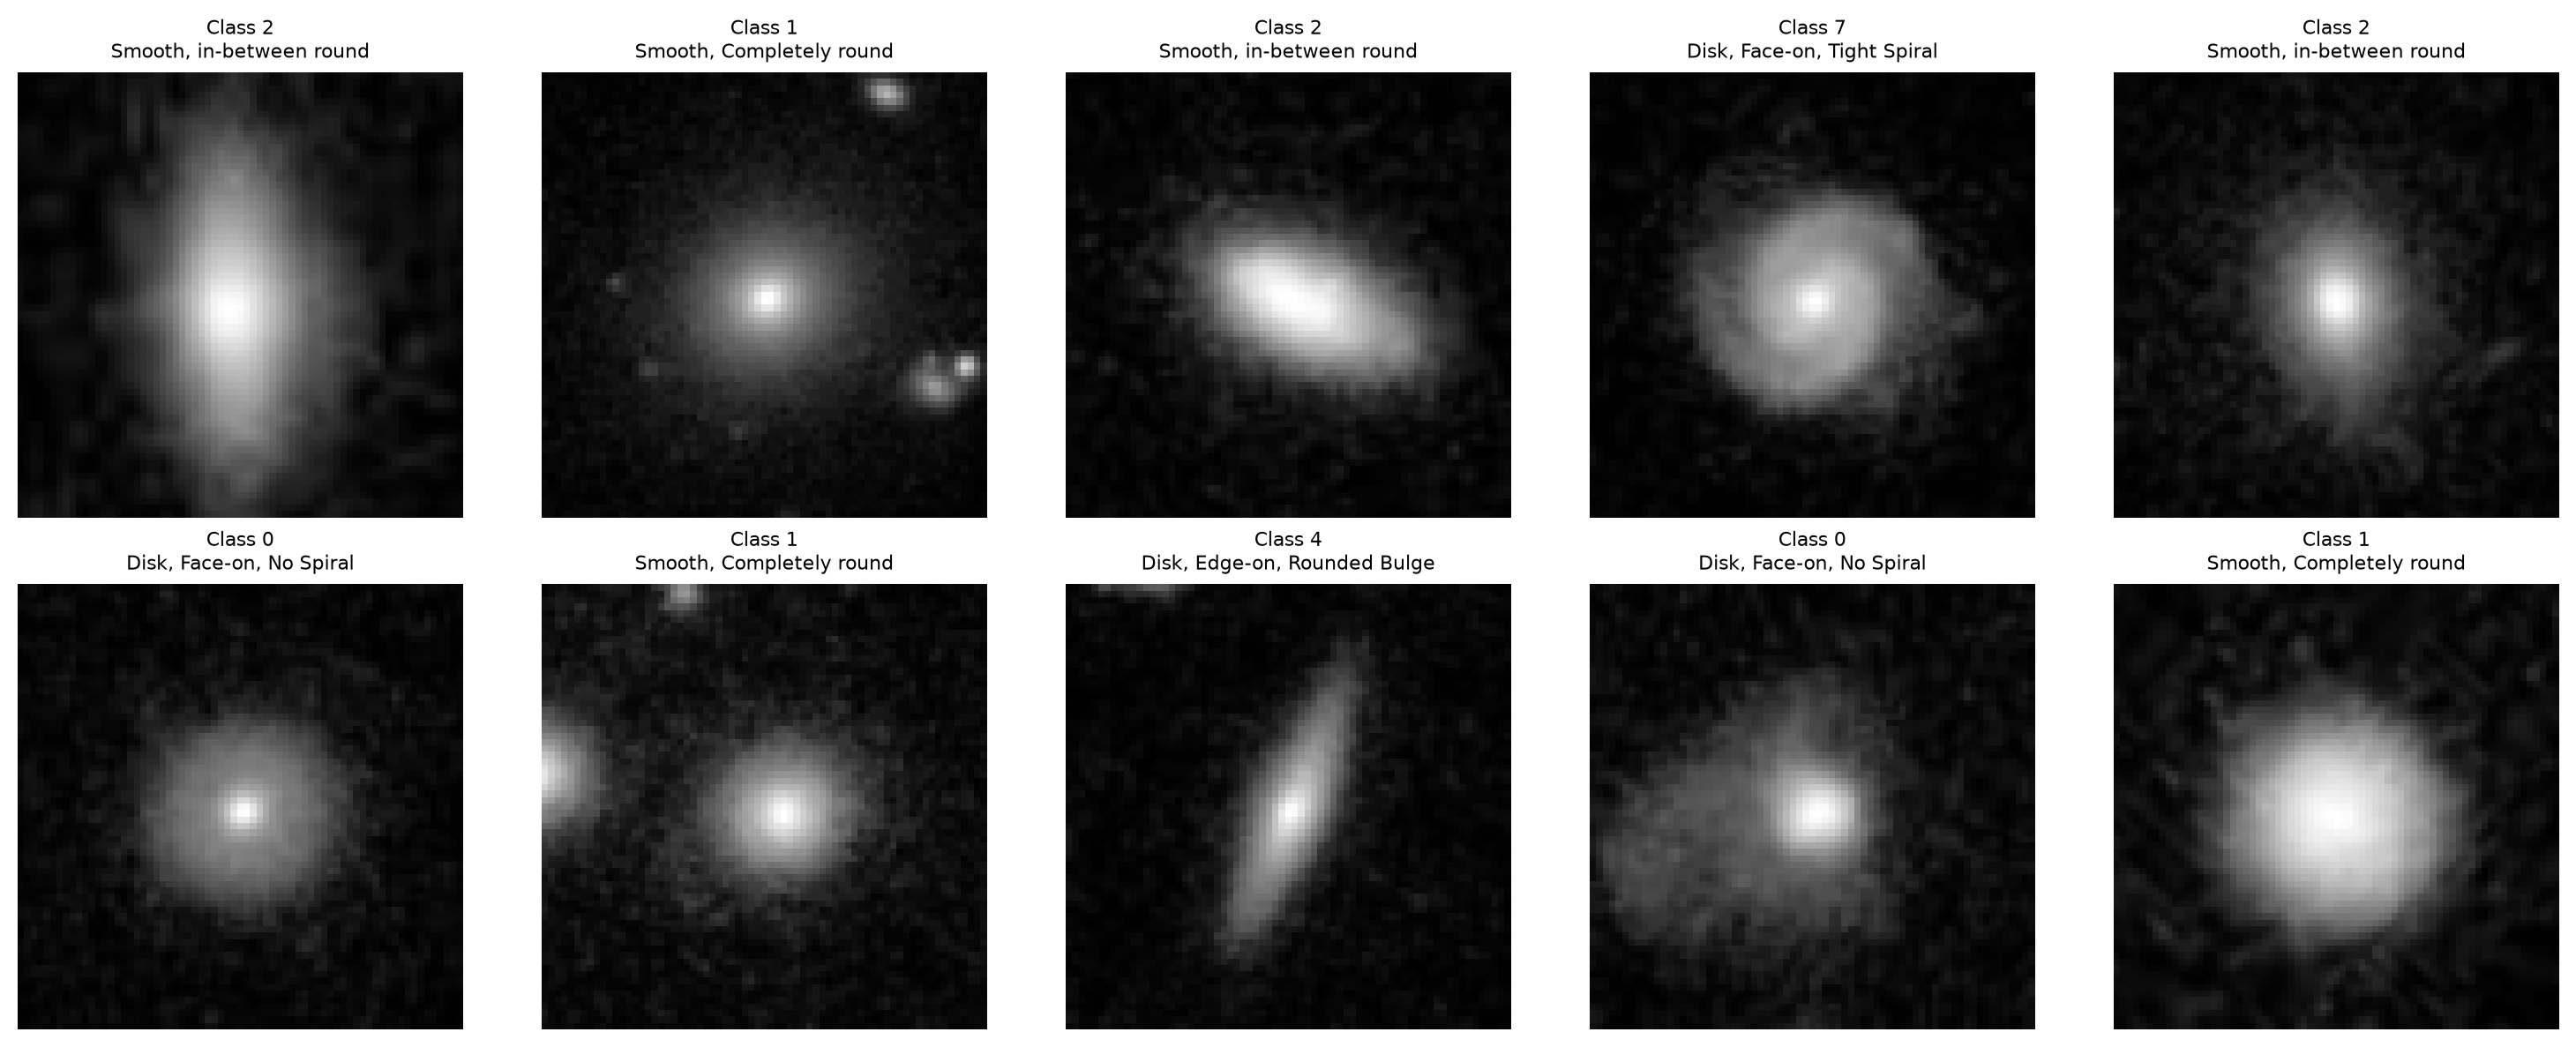

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

idx = np.random.randint(0, labels.shape[0], size=10)

for ax, i in zip(axes.flat, idx):
    ax.imshow(images_gray[i], cmap="gray")
    ax.set_title(f"Class {np.argmax(labels[i])}\n{galaxy10cls_lookup(labels[i])}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
import numpy as np

X_flat = images_gray.reshape(images_gray.shape[0], -1)
y = labels

# Subsample for speed if needed (t-SNE/UMAP get slow above ~10k points)
n_sample = 3000
idx = np.random.choice(X_flat.shape[0], n_sample, replace=False)
X_sub, y_sub = X_flat[idx], y[idx]

In [11]:
y_labels = (np.argmax(y_sub, axis=1))

In [12]:
y_sub.shape[1]

10

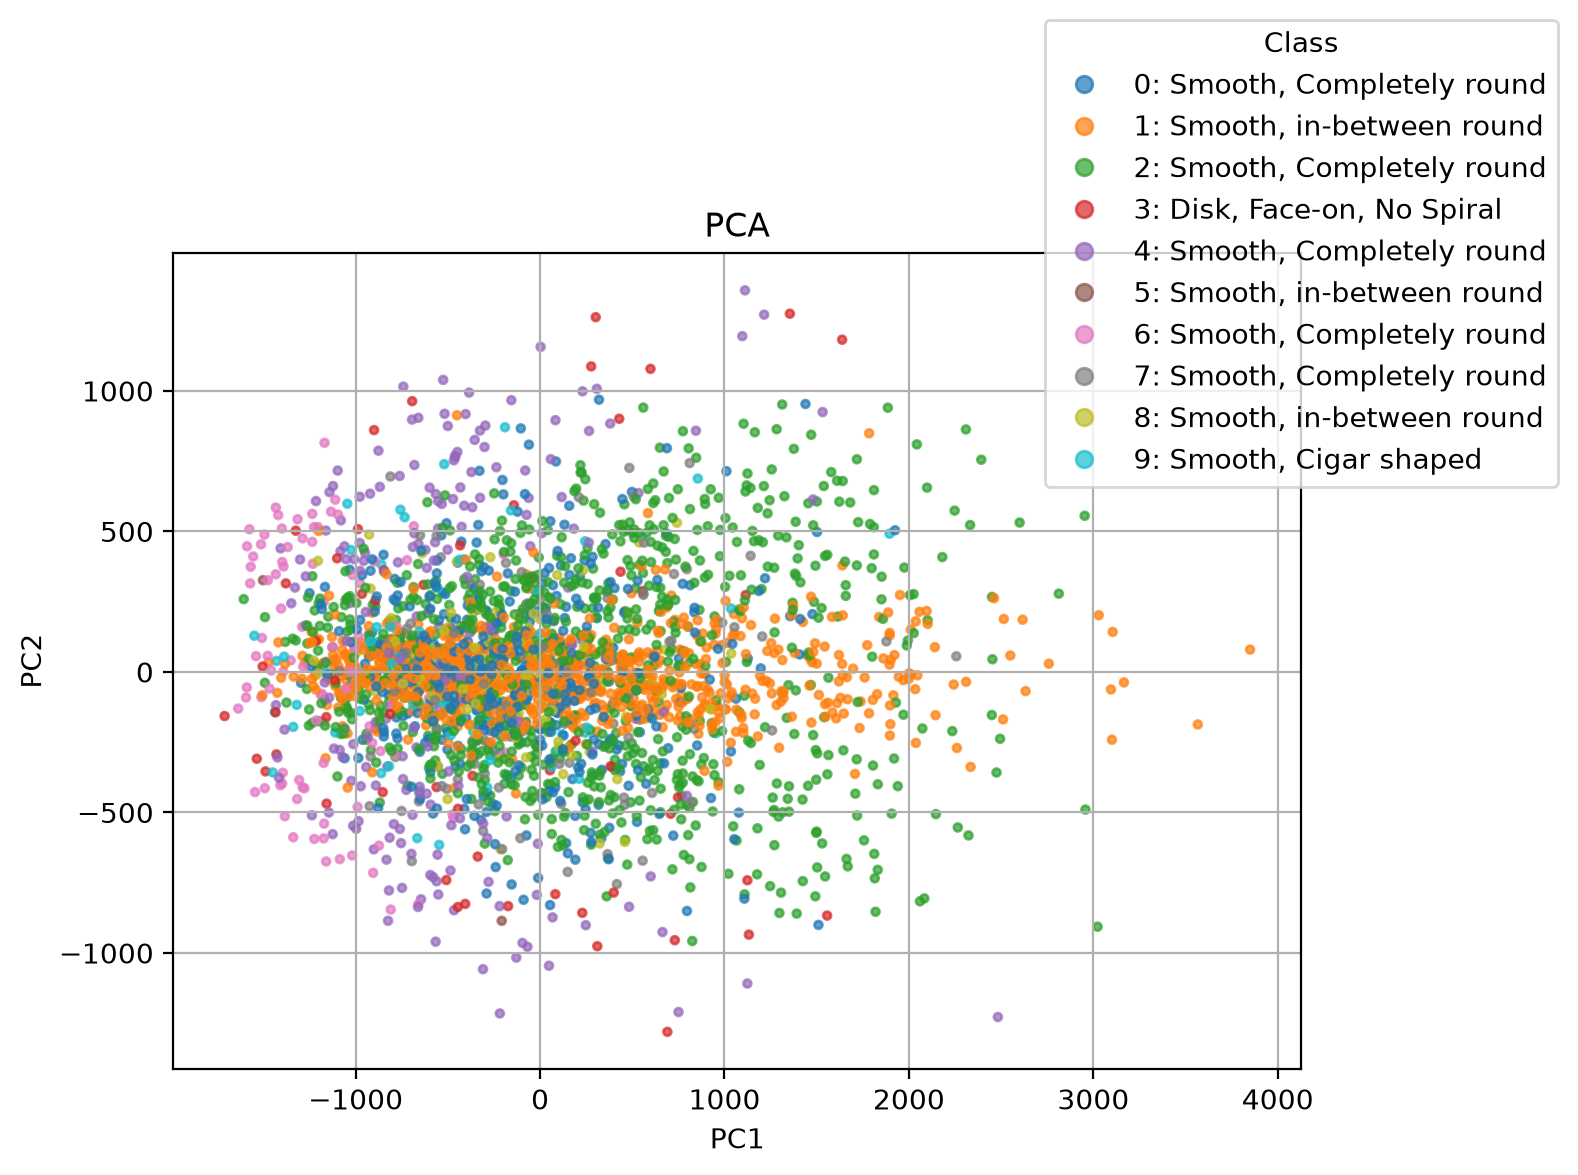

Explained variance: [0.460396   0.07335847]


In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sub)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y_labels, cmap='tab10', s=8, alpha=0.7)

# Manually build legend handles with class names
handles, _ = scatter.legend_elements()
legend_labels = [f"{i}: {galaxy10cls_lookup(y_labels[i])}" for i in range(y_sub.shape[1])]
plt.legend(handles, legend_labels, title="Class", bbox_to_anchor=(1,1), loc="center")
# plt.legend(*scatter.legend_elements(), title="Class", bbox_to_anchor=(1.05,1))

plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("PCA")
plt.grid()
plt.tight_layout()
plt.savefig("pca.pdf")
plt.show()

print(f"Explained variance: {pca.explained_variance_ratio_}")

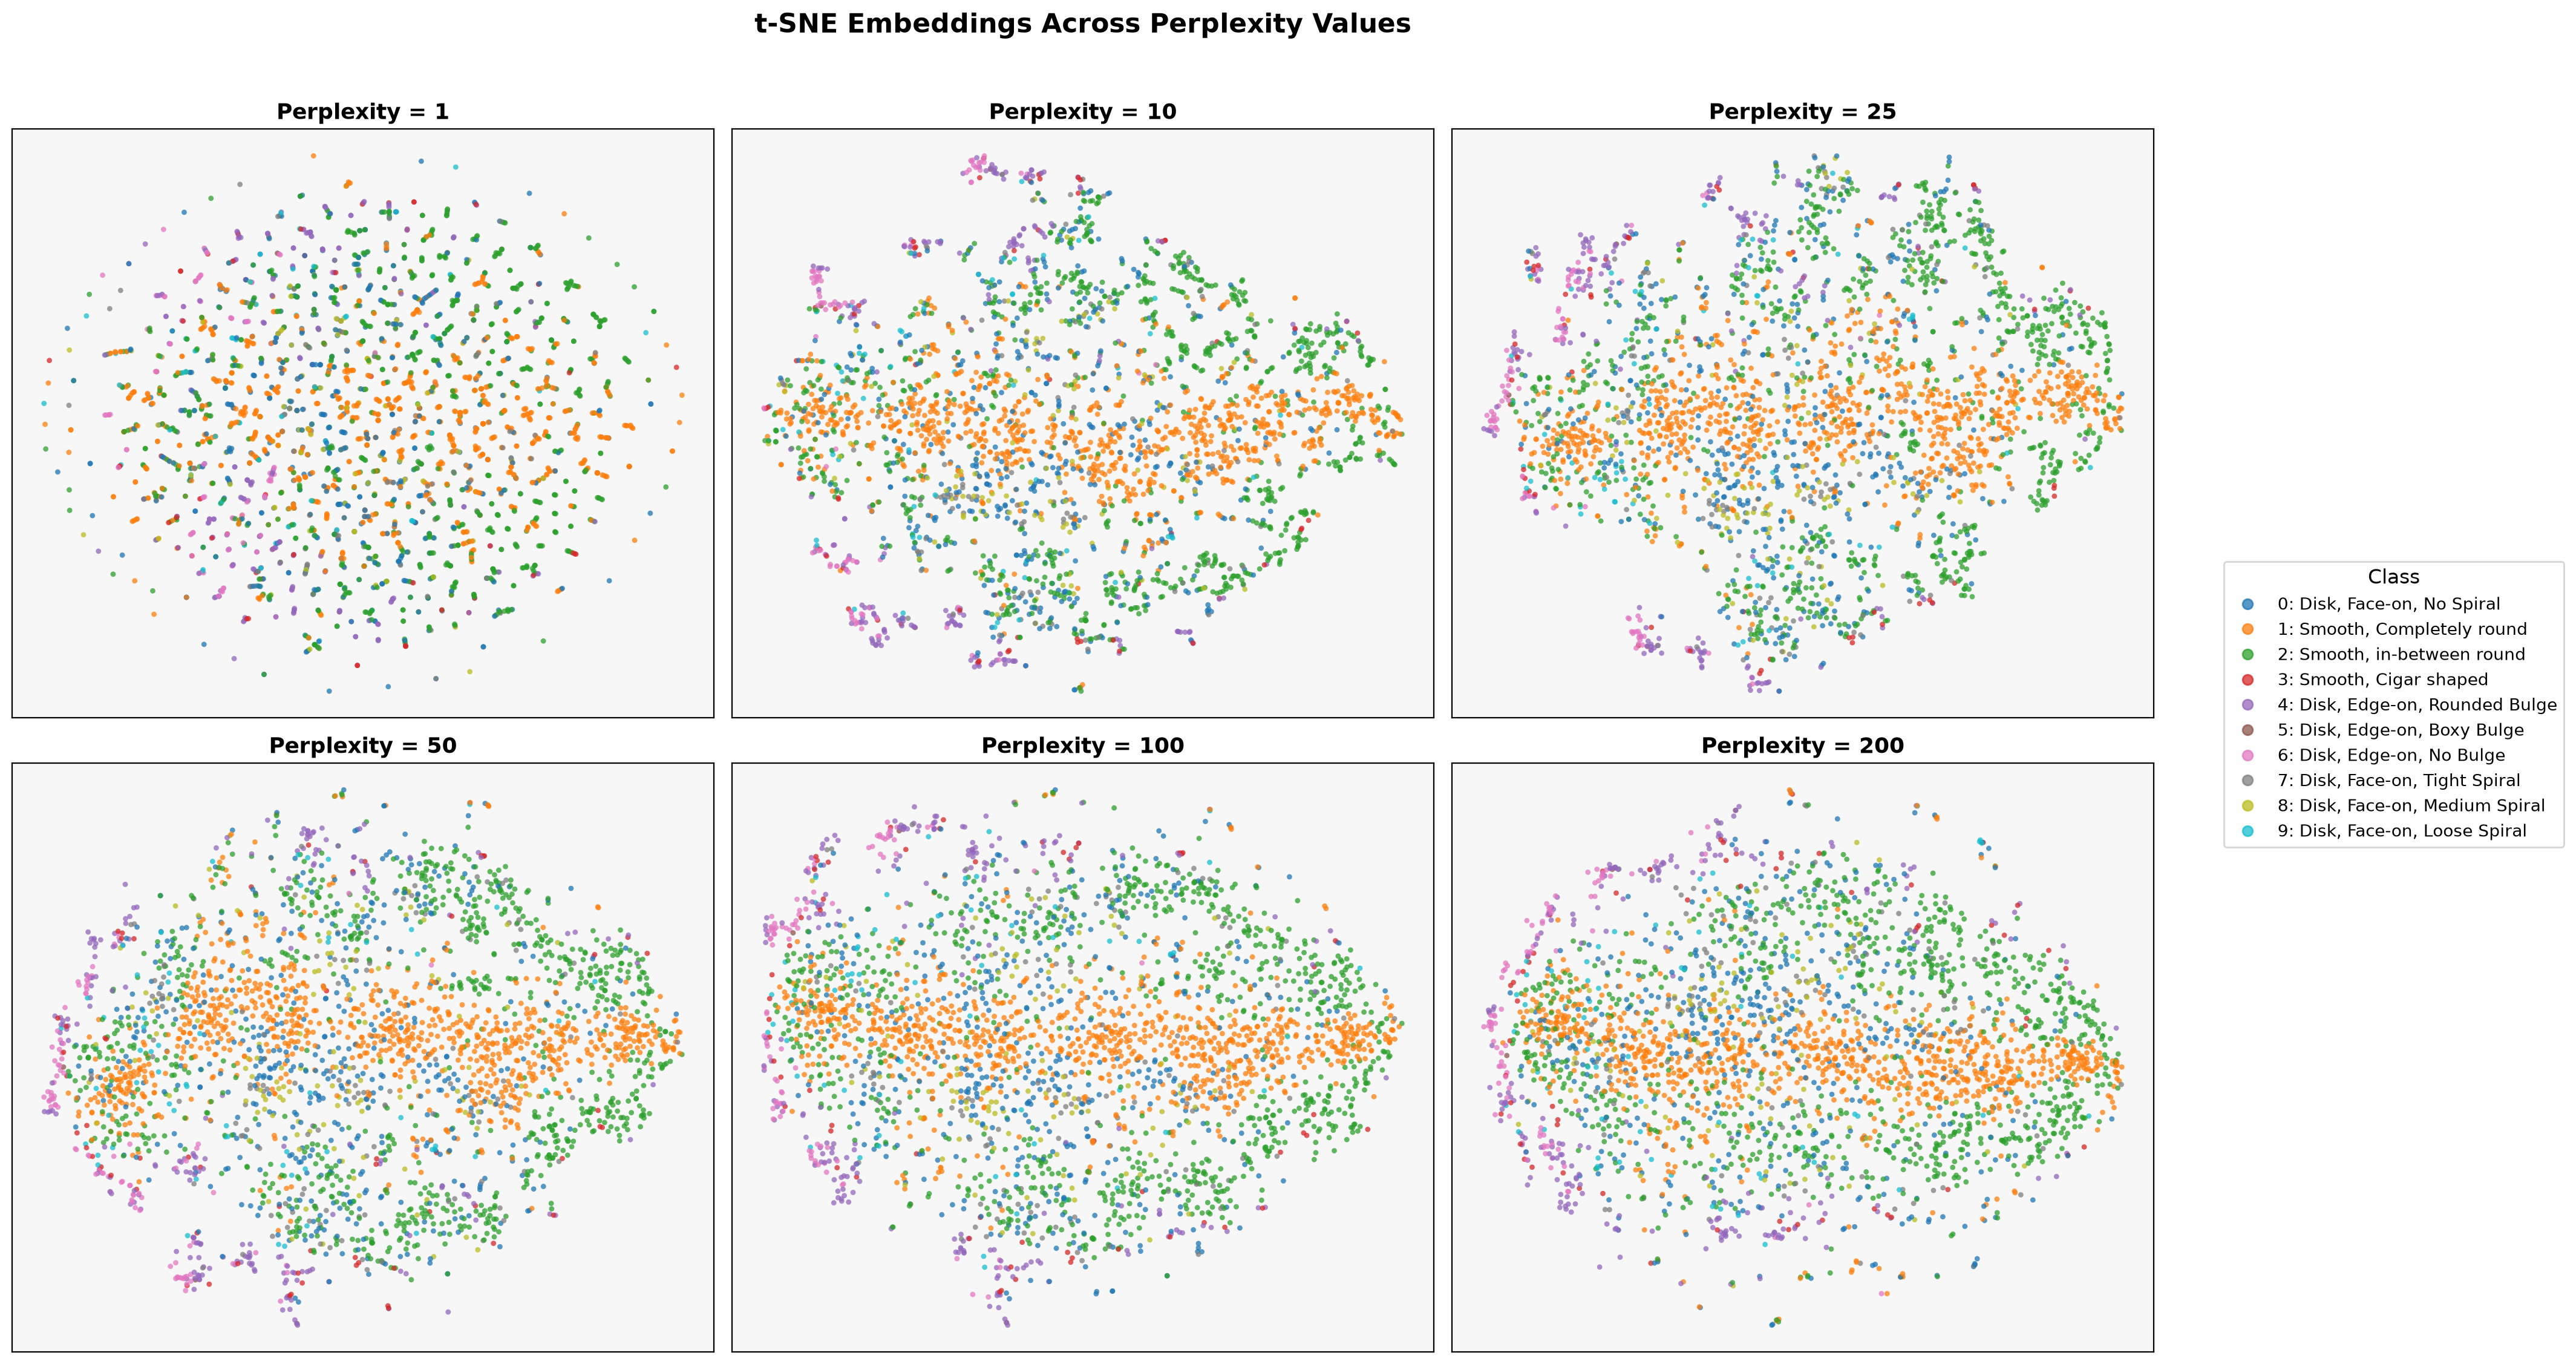

In [14]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Build class name lookup once
n_classes = labels.shape[1]
class_names = {c: galaxy10cls_lookup(np.eye(n_classes)[c]) for c in range(n_classes)}

X_pca50 = PCA(n_components=50).fit_transform(X_sub)

perplexities = [1, 10, 25, 50, 100, 200]
n_plots = len(perplexities)
ncols = 3
nrows = int(np.ceil(n_plots / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5.5*nrows))
axes = axes.flatten()

scatter = None  # will hold the last scatter object for legend handles

for ax, perp in zip(axes, perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, init='pca')
    X_tsne = tsne.fit_transform(X_pca50)
    
    scatter = ax.scatter(X_tsne[:,0], X_tsne[:,1], c=y_labels, cmap='tab10', 
                          s=10, alpha=0.75, edgecolors='none')
    ax.set_title(f"Perplexity = {perp}", fontsize=13, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_facecolor('#f7f7f7')

# Hide any unused subplot axes (if perplexities count doesn't fill the grid)
for ax in axes[n_plots:]:
    ax.axis('off')

# One shared legend, built from the last scatter's handles
handles, _ = scatter.legend_elements()
legend_labels = [f"{i}: {class_names[i]}" for i in range(n_classes)]
fig.legend(handles, legend_labels, title="Class", 
           bbox_to_anchor=(1.02, 0.5), loc='center left', fontsize=10, title_fontsize=12)

fig.suptitle("t-SNE Embeddings Across Perplexity Values", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("tsne_perplexity.pdf")
plt.show()

/Users/leo/Documents/github/galaxy_class/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/leo/Documents/github/galaxy_class/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


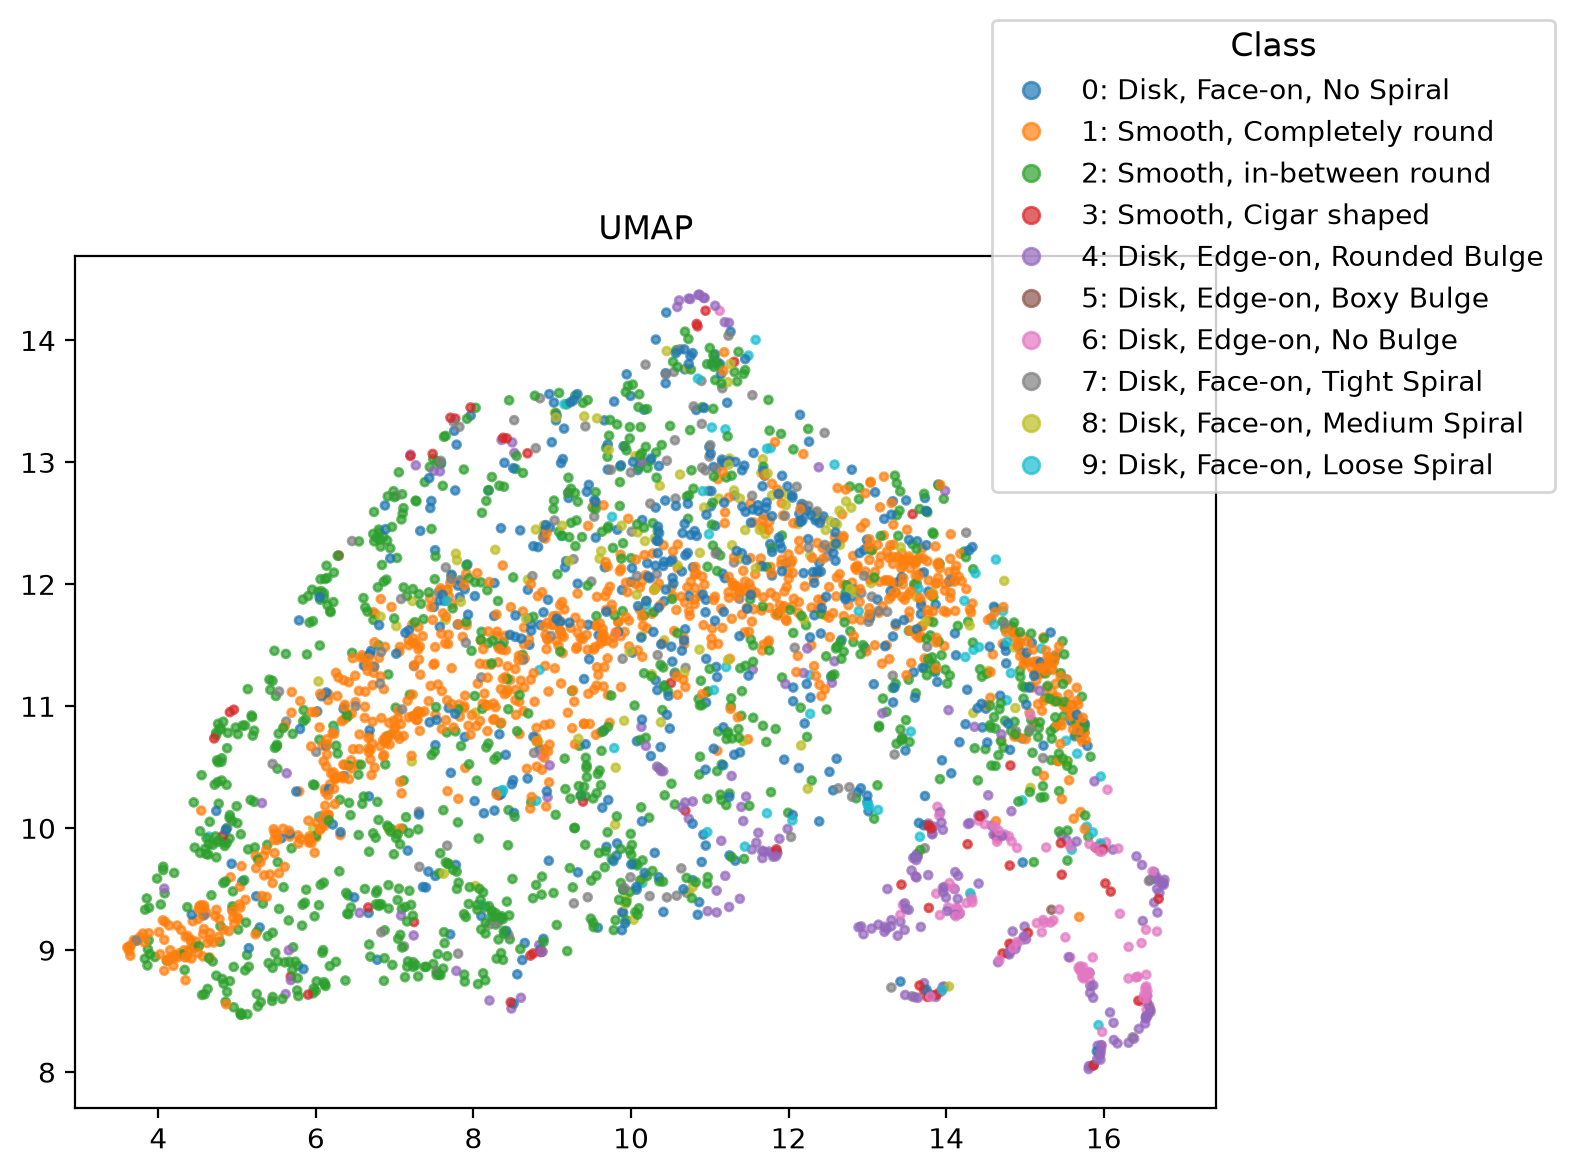

In [15]:
import umap

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_sub)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_umap[:,0], X_umap[:,1], c=y_labels, cmap='tab10', s=8, alpha=0.7)
handles, _ = scatter.legend_elements()
legend_labels = [f"{i}: {class_names[i]}" for i in range(n_classes)]
plt.legend(handles, legend_labels, title="Class", 
           bbox_to_anchor=(1.05, 1), loc='center', fontsize=10, title_fontsize=12)

plt.title("UMAP")
plt.tight_layout()
plt.savefig("umap.pdf")
plt.show()

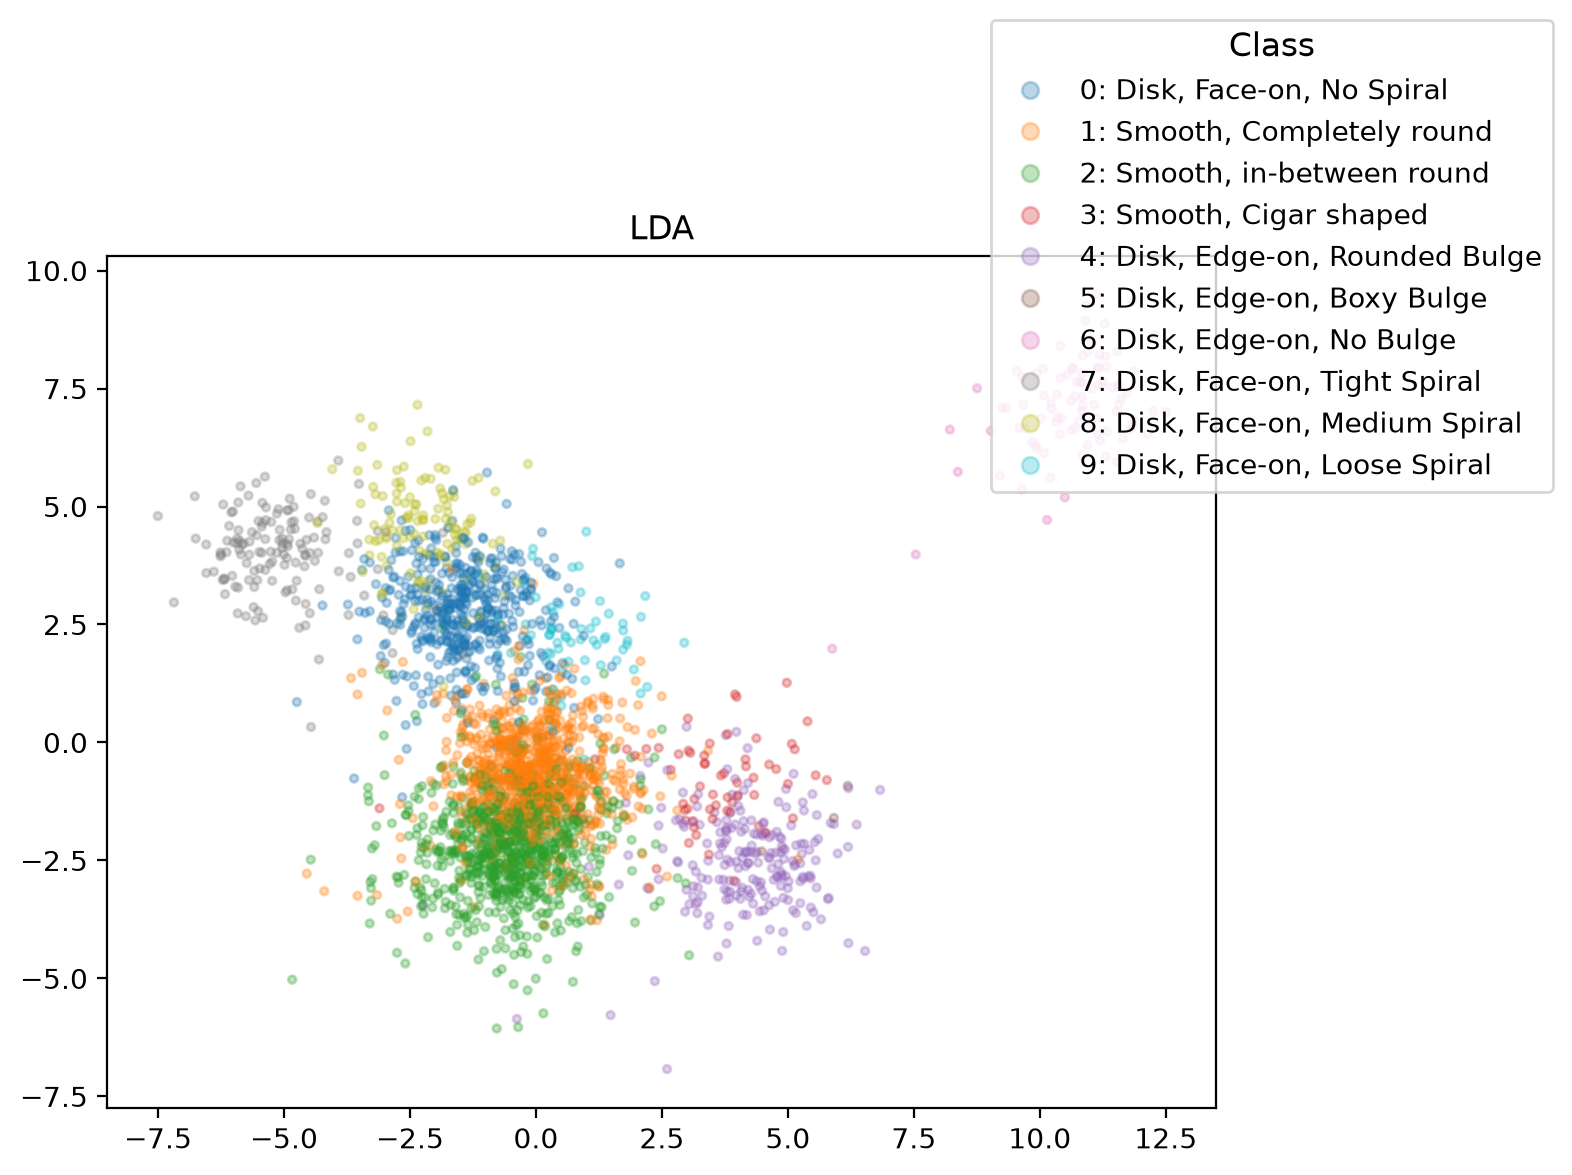

In [16]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)  
X_lda = lda.fit_transform(X_sub, y_labels)  

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_lda[:,0], X_lda[:,1], c=y_labels, cmap='tab10', s=8, alpha=0.3)
handles, _ = scatter.legend_elements()
legend_labels = [f"{i}: {class_names[i]}" for i in range(n_classes)]
plt.legend(handles, legend_labels, title="Class", 
           bbox_to_anchor=(1.05, 1), loc='center', fontsize=10, title_fontsize=12)

plt.title("LDA")
plt.tight_layout()
plt.savefig("lda.pdf")
plt.show()

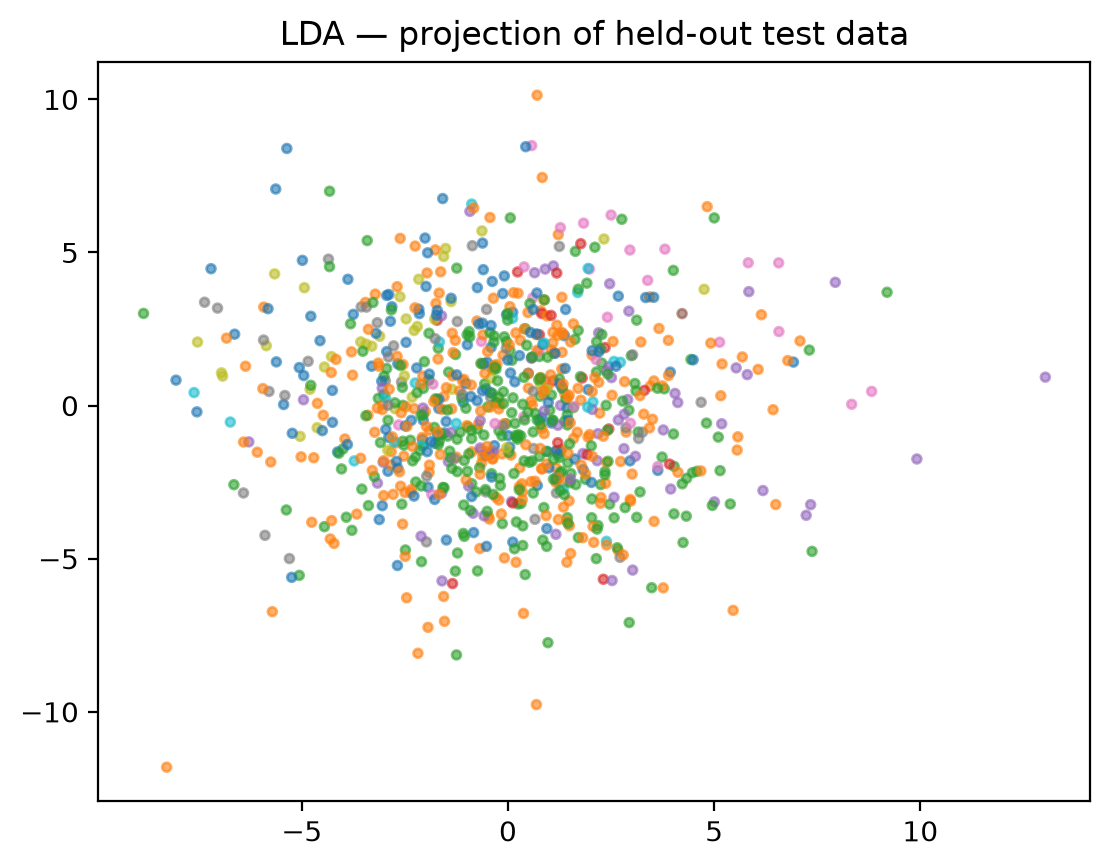

In [17]:
# overfitting check

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_sub, y_labels, test_size=0.3, random_state=42, stratify=y_sub)

lda = LinearDiscriminantAnalysis(n_components=2)
lda.fit(X_train, y_train)

X_test_lda = lda.transform(X_test)  # project *unseen* points using the fitted LDA

plt.scatter(X_test_lda[:,0], X_test_lda[:,1], c=y_test, cmap='tab10', s=10, alpha=0.6)
plt.title("LDA — projection of held-out test data")
plt.savefig("lda-test.pdf")
plt.show()